# Global Sensitivity Analysis of the SAC-SMA Rainfall-Runoff Model
## A ShapleyX Example with Correlated Inputs

This notebook demonstrates a complete ShapleyX workflow for the **Sacramento Soil Moisture Accounting (SAC-SMA)** model:

1. **Phase 1 — Build an RS-HDMR surrogate** of the NSE response using QMC Sobol (scrambled + shifted) training data
2. **Phase 2 — Compute Shapley Effects under independent inputs** (standard RS-HDMR)  
3. **Phase 3 — Compute Shapley Effects under correlated inputs** using MC Shapley with a Gaussian copula and a literature-based correlation matrix from Vrugt et al. (2006)
4. **Phase 4 — Compare** independent vs correlated sensitivity rankings

> **Reference:** Vrugt, J.A., et al. (2006). *Application of stochastic parameter optimization to the Sacramento Soil Moisture Accounting model.* Journal of Hydrology, 325, 288–307.

> **Catchment:** St Helens Creek, North Queensland (area = 120.5 km²), daily data from Feb 1973 – Dec 2018.

In [27]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats.qmc import Sobol
import warnings
import sys
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

# ShapleyX
from shapleyx import rshdmr
from shapleyx.utilities.mc_shapley import (
    GaussianCopulaUniform,
    shapley_effects,
)

# SAC-SMA model
data_dir = os.path.join(os.path.dirname(os.path.abspath('')), 'sac_sma_data')
sys.path.insert(0, data_dir)
from sacramento import sacsma

print('All imports OK')

All imports OK


---
## 1. Load Forcing Data and Observations

We have ~46 years of daily rainfall, PET, and observed discharge for St Helens Creek (North Queensland).
Catchment area: **120.5 km²**.

In [2]:
df_forcing = pd.read_csv(f'{data_dir}/st_helens_forcing_original.csv', parse_dates=['date'], dayfirst=True)
print(f'Forcing data: {len(df_forcing)} daily timesteps')
print(f'Date range: {df_forcing.date.iloc[0].date()} to {df_forcing.date.iloc[-1].date()}')

CATCHMENT_AREA_M2 = 120_500_000.0

prcp = df_forcing['rainfall'].values
pet  = df_forcing['pet'].values
q_obs = df_forcing['Q_CUMEC'].values

def flow_mm_to_cumec(flow_mm):
    return flow_mm * CATCHMENT_AREA_M2 / 1000.0 / 86400.0

WARMUP_DAYS = 365
print(f'Warm-up: {WARMUP_DAYS} days')
print(f'Evaluation: day {WARMUP_DAYS+1} to {len(df_forcing)} ({len(df_forcing)-WARMUP_DAYS} timesteps)')

Forcing data: 16763 daily timesteps
Date range: 1973-02-08 to 2018-12-31
Warm-up: 365 days
Evaluation: day 366 to 16763 (16398 timesteps)


---
## 2. Define the SAC-SMA NSE Wrapper

This function takes a 14-parameter vector, runs the Numba-JIT-compiled SAC-SMA model, converts the simulated flow from mm/day to m³/s, and computes the **Nash-Sutcliffe Efficiency (NSE)** against observed discharge.

We first run a warmup call to trigger Numba compilation.

In [3]:
def nse_from_params(params, warmup=WARMUP_DAYS):
    flow_mm = sacsma(prcp, pet, params)
    sim = flow_mm_to_cumec(flow_mm[warmup:])
    obs = q_obs[warmup:]
    residual = obs - sim
    numerator = np.sum(residual ** 2)
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    return 1.0 - numerator / denominator if denominator > 0 else -np.inf

# Warm-up (triggers Numba JIT)
params_default = np.array([44.13, 52.76, 80.87, 112.70, 52.81, 0.084, 0.490,
                           0.0148, 0.133, 35.31, 2.532, 0.00578, 0.424, 0.0093])
nse_default = nse_from_params(params_default)
print(f'NSE at default parameters: {nse_default:.4f}')

NSE at default parameters: 0.8406


---
## 3. Generate Training Data: QMC Sobol Sequence (4096 samples)

We use a **scrambled Sobol sequence** with **Cranley-Patterson rotation** (random shift) to produce 4096 well-spaced samples in the 14-dimensional unit hypercube. Each dimension is then mapped to the physically plausible range from `es_parameters.csv`.

In [4]:
N_PARAMS = 14
N_SAMPLES = 4096

param_names = ['Uztwm', 'Uzfwm', 'Lztwm', 'Lzfpm', 'Lzfsm',
               'Adimp', 'Uzk', 'Lzpk', 'Lzsk', 'Zperc',
               'Rexp', 'Pctim', 'Pfree', 'Side']

param_lower = np.array([30, 10, 20, 40, 15, 0, 0.2, 0.001, 0.03, 0, 0, 0, 0, 0])
param_upper = np.array([125, 75, 300, 600, 300, 0.2, 0.9, 0.03, 0.8, 80, 5, 0.05, 0.8, 0.8])
param_ranges = param_upper - param_lower

print(f'Parameter space: {N_PARAMS} dimensions x {N_SAMPLES} Sobol samples')
for i, name in enumerate(param_names):
    print(f'  {name:>6s}: [{param_lower[i]:8.3f}, {param_upper[i]:8.3f}]')

Parameter space: 14 dimensions x 4096 Sobol samples
   Uztwm: [  30.000,  125.000]
   Uzfwm: [  10.000,   75.000]
   Lztwm: [  20.000,  300.000]
   Lzfpm: [  40.000,  600.000]
   Lzfsm: [  15.000,  300.000]
   Adimp: [   0.000,    0.200]
     Uzk: [   0.200,    0.900]
    Lzpk: [   0.001,    0.030]
    Lzsk: [   0.030,    0.800]
   Zperc: [   0.000,   80.000]
    Rexp: [   0.000,    5.000]
   Pctim: [   0.000,    0.050]
   Pfree: [   0.000,    0.800]
    Side: [   0.000,    0.800]


In [5]:
sobol_gen = Sobol(d=N_PARAMS, scramble=True, seed=42)
X_uniform = sobol_gen.random(n=N_SAMPLES)

# Cranley-Patterson rotation
rng = np.random.default_rng(123)
shift = rng.uniform(0, 1, size=N_PARAMS)
X_uniform = (X_uniform + shift) % 1.0

X_params = param_lower + X_uniform * param_ranges
print(f'Sobol samples shape: {X_params.shape}')
print(f'First 3 samples:')
for i in range(min(3, N_SAMPLES)):
    print(f'  [{i}] ' + ', '.join(f'{v:.2f}' for v in X_params[i]))

Sobol samples shape: (4096, 14)
First 3 samples:
  [0] 40.77, 66.43, 27.50, 173.18, 150.05, 0.13, 0.63, 0.03, 0.51, 0.36, 0.21, 0.05, 0.16, 0.65
  [1] 65.53, 45.54, 132.44, 68.88, 36.73, 0.04, 0.29, 0.02, 0.13, 57.01, 4.46, 0.03, 0.45, 0.32
  [2] 72.51, 49.16, 232.04, 310.12, 257.91, 0.17, 0.72, 0.02, 0.03, 39.35, 3.77, 0.02, 0.80, 0.01


---
## 4. Evaluate SAC-SMA for All Training Samples

This runs the model 4096 times (~30–60 seconds with Numba JIT). Each run simulates ~46 years of daily streamflow.

In [6]:
print('Evaluating 4096 parameter sets...')
Y_nse = np.array([nse_from_params(X_params[i]) for i in range(N_SAMPLES)])

valid = Y_nse > -np.inf
print(f'NSE distribution ({valid.sum()} valid samples):')
Yv = Y_nse[valid]
print(f'  Mean:   {Yv.mean():.4f}')
print(f'  Std:    {Yv.std():.4f}')
print(f'  Min:    {Yv.min():.4f}')
print(f'  Max:    {Yv.max():.4f}')
print(f'  Median: {np.median(Yv):.4f}')
print(f'  NSE > 0: {(Yv > 0).mean()*100:.1f}% (better than mean-flow benchmark)')

Evaluating 4096 parameter sets...
NSE distribution (4096 valid samples):
  Mean:   0.6927
  Std:    0.0977
  Min:    0.3339
  Max:    0.8580
  Median: 0.7029
  NSE > 0: 100.0% (better than mean-flow benchmark)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


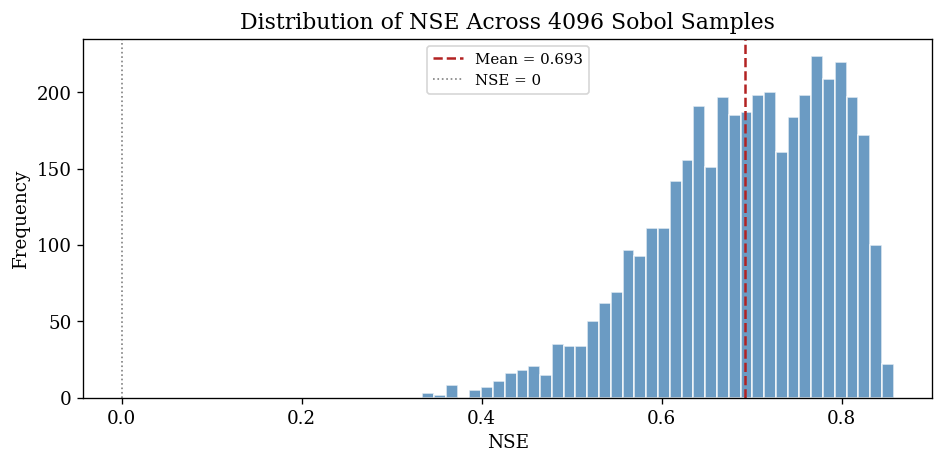

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Yv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(Yv.mean(), color='firebrick', ls='--', lw=1.5, label=f'Mean = {Yv.mean():.3f}')
ax.axvline(0, color='grey', ls=':', lw=1, label='NSE = 0')
ax.set_xlabel('NSE')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of NSE Across 4096 Sobol Samples')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nse_distribution.eps')
plt.savefig('nse_distribution.svg')
plt.show()

---
## 5. Build the RS-HDMR Surrogate Model

We train the surrogate using:
- `polys=[10, 6, 2]` — 1st-order terms up to degree 10, 2nd-order up to degree 6, 3rd-order up to degree 2
- `method='omp_cv'` — OMP with CV (suitable for ~9K basis functions)

Training RS-HDMR surrogate (streaming OMP-CV)...
Found a DataFrame

Transforming data to unit hypercube

Feature: Uztwm, Min Value: 30.0162, Max Value: 124.9915
Feature: Uzfwm, Min Value: 10.0222, Max Value: 74.9941
Feature: Lztwm, Min Value: 20.0122, Max Value: 299.9523
Feature: Lzfpm, Min Value: 40.1022, Max Value: 599.9162
Feature: Lzfsm, Min Value: 15.1039, Max Value: 299.9918
Feature: Adimp, Min Value: 0.0000, Max Value: 0.1999
Feature: Uzk, Min Value: 0.2000, Max Value: 0.8999
Feature: Lzpk, Min Value: 0.0010, Max Value: 0.0300
Feature: Lzsk, Min Value: 0.0302, Max Value: 0.8000
Feature: Zperc, Min Value: 0.0116, Max Value: 79.9933
Feature: Rexp, Min Value: 0.0008, Max Value: 4.9996
Feature: Pctim, Min Value: 0.0000, Max Value: 0.0500
Feature: Pfree, Min Value: 0.0001, Max Value: 0.7999
Feature: Side, Min Value: 0.0001, Max Value: 0.8000

Building basis functions

Basis functions of 1 order : 140
Basis functions of 2 order : 5824
Basis functions of 3 order : 2912
Total basis func

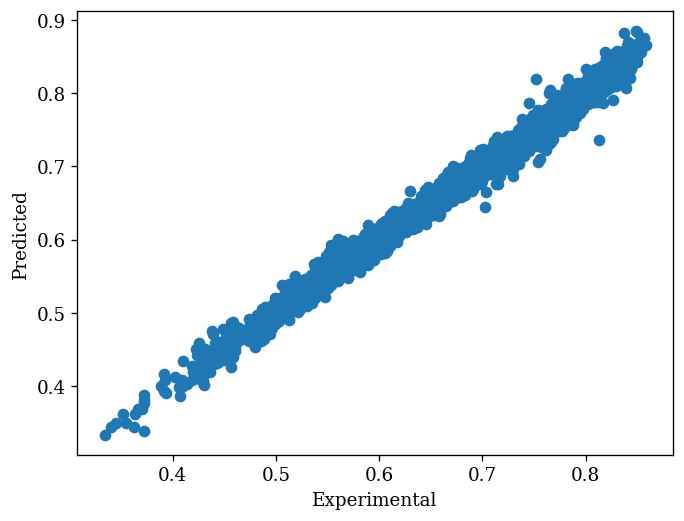


                  Completed all analysis
                 ------------------------

The secret of success is constancy to purpose.  Benjamin
Disraeli


Surrogate training complete.


In [8]:
df_train = pd.DataFrame(X_params, columns=param_names)
df_train['Y'] = Y_nse

print('Training RS-HDMR surrogate (streaming OMP-CV)...')
analyzer = rshdmr(
    data_file=df_train,
    polys=[10, 8, 2],
    method='omp_cv',
    n_iter=400,
    test_size=0.25,
    verbose=True,
    resampling=False,
    n_jobs=4,
)

sobol, shap, total = analyzer.run_all()
print('\nSurrogate training complete.')

---
## 6. RS-HDMR Shapley Effects (Independent Inputs)

The standard RS-HDMR Shapley effects assume **independent inputs**. They redistribute interaction variance equally among the participating variables. This is our baseline.

RS-HDMR Shapley Effects — Independent Inputs:
    label   effect  scaled effect
0   Uztwm 0.003016       0.003050
1   Uzfwm 0.004344       0.004393
2   Lztwm 0.042440       0.042911
3   Lzfpm 0.246484       0.249221
4   Lzfsm 0.203561       0.205822
5   Adimp 0.082821       0.083741
6     Uzk 0.013455       0.013604
7    Lzpk 0.049998       0.050554
8    Lzsk 0.061728       0.062414
9   Zperc 0.063062       0.063762
10   Rexp 0.162799       0.164607
11  Pctim 0.007306       0.007387
12  Pfree 0.000865       0.000875
13   Side 0.047137       0.047661


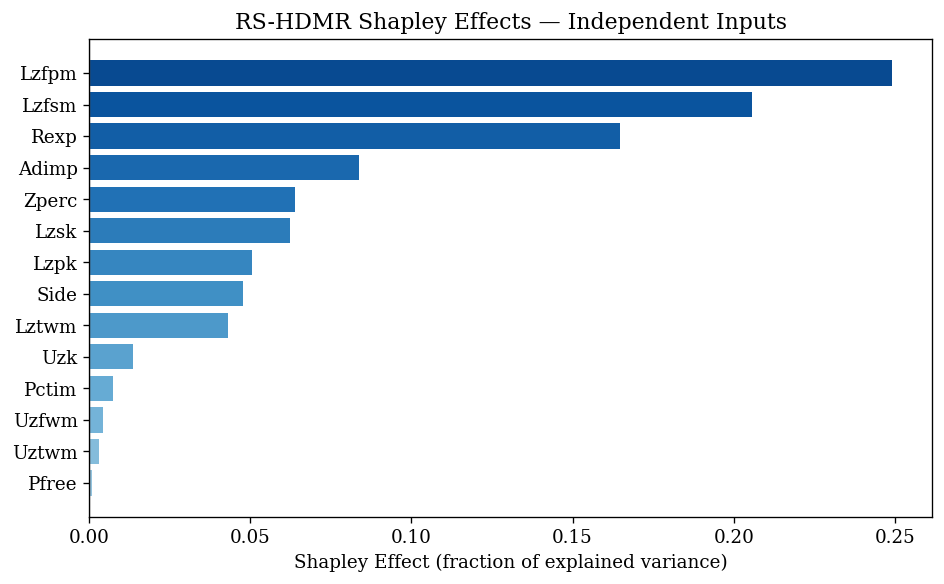

In [9]:
display_col = 'scaled effect' if 'scaled effect' in shap.columns else 'effect'
print(f'RS-HDMR Shapley Effects — Independent Inputs:')
print(shap.to_string(float_format=lambda x: f'{x:.6f}'))

shap_sorted = shap.sort_values(display_col, ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(shap_sorted)))
ax.barh(range(len(shap_sorted)), shap_sorted[display_col].values, color=colors)
ax.set_yticks(range(len(shap_sorted)))
ax.set_yticklabels(shap_sorted['label'].values)
ax.set_xlabel('Shapley Effect (fraction of explained variance)')
ax.set_title('RS-HDMR Shapley Effects — Independent Inputs')
ax.axvline(0, color='grey', lw=0.8)
plt.tight_layout()
plt.savefig('shapley_independent.png')
plt.show()

---
## 7. Build the Parameter Correlation Matrix

We construct the correlation matrix from **Vrugt et al. (2006, Table 2)** — the full 13×13 posterior correlation matrix from MCMC (SCEM-UA) calibration of SAC-SMA on the Leaf River, Mississippi. Parameter SIDE was fixed (not calibrated), so its correlations are set to zero.

This matrix defines the dependence structure for the Gaussian copula used in MC Shapley.

In [10]:
# Vrugt et al. (2006) Table 2 — 13x13 correlation matrix
# Vrugt order: UZTWM, UZFWM, UZK, PCTIM, ADIMP, ZPERC, REXP,
#               LZTWM, LZFSM, LZFPM, LZSK, LZPK, PFREE
corr_vrugt = np.array([
    [ 1.00, -0.02, -0.04,  0.19,  0.36, -0.01,  0.11, -0.84, -0.17,  0.28,  0.17,  0.16,  0.57],
    [-0.02,  1.00, -0.53,  0.05,  0.01,  0.15,  0.11, -0.01, -0.08,  0.22, -0.15, -0.18, -0.33],
    [-0.04, -0.53,  1.00, -0.01, -0.41, -0.13, -0.03,  0.07, -0.11, -0.01, -0.02,  0.08,  0.08],
    [ 0.19,  0.05, -0.01,  1.00, -0.16,  0.01,  0.03, -0.14,  0.01,  0.02, -0.08,  0.02, -0.04],
    [ 0.36,  0.01, -0.41, -0.16,  1.00,  0.07,  0.04, -0.21, -0.15,  0.09,  0.17,  0.15,  0.31],
    [-0.01,  0.15, -0.13,  0.01,  0.07,  1.00,  0.05,  0.06, -0.06, -0.10, -0.13,  0.02,  0.00],
    [ 0.11,  0.11, -0.03,  0.03,  0.04,  0.05,  1.00, -0.03,  0.65,  0.68,  0.24, -0.10, -0.12],
    [-0.84, -0.01,  0.07, -0.14, -0.21,  0.06, -0.03,  1.00,  0.28, -0.16, -0.14, -0.23, -0.63],
    [-0.17, -0.08, -0.11,  0.01, -0.15, -0.06,  0.65,  0.28,  1.00,  0.41, -0.33, -0.55, -0.36],
    [ 0.28,  0.22, -0.01,  0.02,  0.09, -0.10,  0.68, -0.16,  0.41,  1.00,  0.06, -0.43, -0.26],
    [ 0.17, -0.15, -0.02, -0.08,  0.17, -0.13,  0.24, -0.14, -0.33,  0.06,  1.00,  0.60,  0.41],
    [ 0.16, -0.18,  0.08,  0.02,  0.15,  0.02, -0.10, -0.23, -0.55, -0.43,  0.60,  1.00,  0.56],
    [ 0.57, -0.33,  0.08, -0.04,  0.31,  0.00, -0.12, -0.63, -0.36, -0.26,  0.41,  0.56,  1.00],
])

# Map Vrugt order -> our parameter order
# Ours: Uztwm(0), Uzfwm(1), Lztwm(2), Lzfpm(3), Lzfsm(4), Adimp(5), Uzk(6),
#       Lzpk(7),  Lzsk(8),  Zperc(9), Rexp(10), Pctim(11), Pfree(12), Side(13)
vrugt_to_our = [0, 1, 6, 11, 5, 9, 10, 2, 4, 3, 8, 7, 12]

corr_14 = np.eye(N_PARAMS)
for i, vi in enumerate(vrugt_to_our):
    for j, vj in enumerate(vrugt_to_our):
        corr_14[vi, vj] = corr_vrugt[i, j]

# Ensure symmetry and positive definiteness
corr_14 = (corr_14 + corr_14.T) / 2
eigvals = np.linalg.eigvalsh(corr_14)
if eigvals.min() < 0:
    corr_14 += np.eye(N_PARAMS) * (-eigvals.min() + 1e-8)

print('Correlation matrix:')
pd.set_option('display.precision', 3)
display(pd.DataFrame(corr_14, index=param_names, columns=param_names))

print('\nStrongest correlations:')
for i in range(N_PARAMS):
    for j in range(i+1, N_PARAMS):
        if abs(corr_14[i, j]) > 0.3:
            print(f'  {param_names[i]:>6s} <-> {param_names[j]:<6s}: rho = {corr_14[i, j]:+.3f}')

Correlation matrix:


,Uztwm,Uzfwm,Lztwm,Lzfpm,Lzfsm,Adimp,Uzk,Lzpk,Lzsk,Zperc,Rexp,Pctim,Pfree,Side
Uztwm,1.00,-0.02,-0.84,0.28,-0.17,0.36,-0.04,0.16,0.17,-0.01,0.11,0.19,0.57,0.0
Uzfwm,-0.02,1.00,-0.01,0.22,-0.08,0.01,-0.53,-0.18,-0.15,0.15,0.11,0.05,-0.33,0.0
Lztwm,-0.84,-0.01,1.00,-0.16,0.28,-0.21,0.07,-0.23,-0.14,0.06,-0.03,-0.14,-0.63,0.0
Lzfpm,0.28,0.22,-0.16,1.00,0.41,0.09,-0.01,-0.43,0.06,-0.10,0.68,0.02,-0.26,0.0
Lzfsm,-0.17,-0.08,0.28,0.41,1.00,-0.15,-0.11,-0.55,-0.33,-0.06,0.65,0.01,-0.36,0.0
Adimp,0.36,0.01,-0.21,0.09,-0.15,1.00,-0.41,0.15,0.17,0.07,0.04,-0.16,0.31,0.0
Uzk,-0.04,-0.53,0.07,-0.01,-0.11,-0.41,1.00,0.08,-0.02,-0.13,-0.03,-0.01,0.08,0.0
Lzpk,0.16,-0.18,-0.23,-0.43,-0.55,0.15,0.08,1.00,0.60,0.02,-0.10,0.02,0.56,0.0
Lzsk,0.17,-0.15,-0.14,0.06,-0.33,0.17,-0.02,0.60,1.00,-0.13,0.24,-0.08,0.41,0.0
Zperc,-0.01,0.15,0.06,-0.10,-0.06,0.07,-0.13,0.02,-0.13,1.00,0.05,0.01,0.00,0.0



Strongest correlations:
   Uztwm <-> Lztwm : rho = -0.840
   Uztwm <-> Adimp : rho = +0.360
   Uztwm <-> Pfree : rho = +0.570
   Uzfwm <-> Uzk   : rho = -0.530
   Uzfwm <-> Pfree : rho = -0.330
   Lztwm <-> Pfree : rho = -0.630
   Lzfpm <-> Lzfsm : rho = +0.410
   Lzfpm <-> Lzpk  : rho = -0.430
   Lzfpm <-> Rexp  : rho = +0.680
   Lzfsm <-> Lzpk  : rho = -0.550
   Lzfsm <-> Lzsk  : rho = -0.330
   Lzfsm <-> Rexp  : rho = +0.650
   Lzfsm <-> Pfree : rho = -0.360
   Adimp <-> Uzk   : rho = -0.410
   Adimp <-> Pfree : rho = +0.310
    Lzpk <-> Lzsk  : rho = +0.600
    Lzpk <-> Pfree : rho = +0.560
    Lzsk <-> Pfree : rho = +0.410


---
## 8. MC Shapley Effects Under Correlated Inputs

We use `GaussianCopulaUniform` with the Vrugt correlation matrix and the Monte Carlo exhaustive method (Owen & Prieur, 2017):
- `k_max=3` — only subsets up to size 3 are enumerated (exact for our 3rd-order surrogate)
- N=2000 Monte Carlo samples per subset
- B=500 bootstrap iterations for 95% confidence intervals

The copula induces dependence in the latent normal space while preserving uniform marginals for each parameter.

In [26]:

print('Computing MC Shapley Effects with correlated inputs...')
print(f'  k_max = 3, N = 2000, B = 500\n')

df_mc = analyzer.get_mc_shapley(
    corr=corr_14,
    N=2000,
    method='exhaustive',
    B=500,
    alpha=0.05,
    random_state=42,
    progress=True,
    k_max=3,
)

print('\nMC Shapley Effects (correlated inputs):')
display(df_mc)

Computing MC Shapley Effects with correlated inputs...
  k_max = 3, N = 2000, B = 500



MC Shapley: 100%|██████████| 1878000/1878000 [00:22<00:00, 84752.11evals/s]



MC Shapley Effects (correlated inputs):


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper,sobol_first_lower,sobol_first_upper,sobol_total_lower,sobol_total_upper
0,Uztwm,0.019,9.616e-05,1.523e-02,NaN,0.005,0.005,0.032,-0.032,0.064,NaN,NaN
1,Uzfwm,0.003,1.435e-05,-4.528e-04,NaN,0.005,-0.010,0.015,-0.042,0.045,NaN,NaN
2,Lztwm,0.060,3.043e-04,7.527e-02,NaN,0.005,0.047,0.072,0.029,0.116,NaN,NaN
3,Lzfpm,0.168,8.578e-04,2.221e-01,NaN,0.005,0.155,0.181,0.178,0.270,NaN,NaN
4,Lzfsm,0.216,1.101e-03,3.342e-01,NaN,0.005,0.203,0.228,0.287,0.381,NaN,NaN
5,Adimp,0.043,2.212e-04,6.166e-02,NaN,0.005,0.030,0.056,0.016,0.105,NaN,NaN
6,Uzk,-0.004,-2.067e-05,-1.307e-02,NaN,0.005,-0.016,0.008,-0.058,0.030,NaN,NaN
7,Lzpk,0.104,5.327e-04,1.697e-01,NaN,0.005,0.092,0.117,0.125,0.211,NaN,NaN
8,Lzsk,0.052,2.642e-04,2.863e-02,NaN,0.005,0.040,0.064,-0.016,0.072,NaN,NaN
9,Zperc,0.040,2.053e-04,6.856e-02,NaN,0.005,0.029,0.053,0.028,0.112,NaN,NaN


---
## 9. Direct MC Shapley on the Original SAC-SMA Model

The section above computed MC Shapley on the **RS-HDMR surrogate**.
Here we estimate them **directly on the SAC-SMA model** using ShapleyX's
built-in support for user-defined functions via the `f` parameter.
This enables a clean comparison: same distribution, same algorithm,
different model function.

We use a smaller sample size ($N = 100$) to keep computation practical.
At $N = 100$ with $k_{\max} = 2$, the evaluation requires
$105 \times 100 \times 2 = 21{,}000$ SAC-SMA evaluations,
taking approximately 5 minutes.


In [42]:
N_direct = 1000
B_direct = 100

def sacsma_nse_wrapper(x):
    """SAC-SMA NSE function taking model parameter vector.
    Note: GaussianCopulaUniform handles the [0,1] → physical mapping."""
    return nse_from_params(x)

print('Computing MC Shapley directly on SAC-SMA model...')
print(f'  Distribution: GaussianCopulaUniform (Vrugt correlations)')
print(f'  N = {N_direct}, B = {B_direct}, k_max = 2')
print(f'  Estimated evals: ~{105 * N_direct * 2:,}')

eff_dir, sh_dir, var_dir, lower_dir, upper_dir = shapley_effects(
    sacsma_nse_wrapper,
    joint_correlated,
    N=N_direct,
    method='exhaustive',
    B=B_direct,
    alpha=0.05,
    random_state=42,
    progress=True,
    k_max=2,
)

df_direct = pd.DataFrame({
    'variable': param_names,
    'effect': eff_dir,
    'value': sh_dir,
    'total_var': var_dir,
    'lower': lower_dir,
    'upper': upper_dir,
})
print('\nDone. Top 5 parameters (direct SAC-SMA):')
print(df_direct.sort_values('effect', ascending=False).head(10).to_string(index=False))


Computing MC Shapley directly on SAC-SMA model...
  Distribution: GaussianCopulaUniform (Vrugt correlations)
  N = 1000, B = 100, k_max = 2
  Estimated evals: ~210,000 (~5 min)


MC Shapley: 100%|██████████| 211000/211000 [05:57<00:00, 589.82evals/s]


In [43]:
# Compute surrogate MC Shapley at same settings for fair comparison
print('Computing surrogate MC Shapley at same N=1000, k_max=2...')
eff_surr, sh_surr, var_surr, lower_surr, upper_surr = shapley_effects(
    analyzer.predict,
    joint_correlated,
    N=N_direct,
    method='exhaustive',
    B=B_direct,
    alpha=0.05,
    random_state=42,
    progress=True,
    k_max=2,
)

df_surrogate = pd.DataFrame({
    'variable': param_names,
    'effect': eff_surr,
    'value': sh_surr,
    'total_var': var_surr,
    'lower': lower_surr,
    'upper': upper_surr,
})

# Merge into comparison table
df_comp_direct = df_direct[['variable', 'effect', 'lower', 'upper']].copy()
df_comp_direct.columns = ['Variable', 'SAC-SMA', 'CI_low', 'CI_high']
df_comp_surr = df_surrogate[['variable', 'effect']].copy()
df_comp_surr.columns = ['Variable', 'Surrogate']

df_compare = df_comp_direct.merge(df_comp_surr, on='Variable')
df_compare['Delta'] = df_compare['SAC-SMA'] - df_compare['Surrogate']
df_compare = df_compare.sort_values('SAC-SMA', ascending=False).reset_index(drop=True)

print('\n=== Direct SAC-SMA vs Surrogate MC Shapley (N=1000, k_max=2) ===')
print(df_compare.to_string(index=False))
print(f'\nSum SAC-SMA: {df_compare["SAC-SMA"].sum():.4f}')
print(f'Sum Surrogate: {df_compare["Surrogate"].sum():.4f}')
print(f'Max |Delta|: {df_compare["Delta"].abs().max():.4f}')


Computing surrogate MC Shapley at same N=100, k_max=2...

Direct SAC-SMA vs Surrogate MC Shapley (N=100, k_max=2):
Variable    SAC-SMA  CI_low  CI_high  Surrogate(k2)      Delta
   Lzfsm  1.963e-01   0.175    0.226      2.016e-01 -5.262e-03
   Lzfpm  1.826e-01   0.158    0.209      1.797e-01  2.824e-03
    Rexp  1.596e-01   0.132    0.190      1.709e-01 -1.127e-02
    Lzpk  1.198e-01   0.097    0.143      1.051e-01  1.469e-02
   Lztwm  8.458e-02   0.052    0.109      8.038e-02  4.203e-03
   Pfree  8.073e-02   0.059    0.108      8.470e-02 -3.969e-03
    Lzsk  5.237e-02   0.026    0.076      4.408e-02  8.296e-03
    Side  4.414e-02   0.013    0.071      4.829e-02 -4.151e-03
   Zperc  4.180e-02   0.018    0.066      4.336e-02 -1.555e-03
   Adimp  3.484e-02   0.012    0.059      4.191e-02 -7.071e-03
     Uzk  1.012e-02  -0.015    0.036      5.006e-03  5.113e-03
   Pctim  2.788e-03  -0.023    0.030      1.436e-03  1.352e-03
   Uztwm -5.840e-04  -0.027    0.024     -5.897e-04  5.730e-06
   

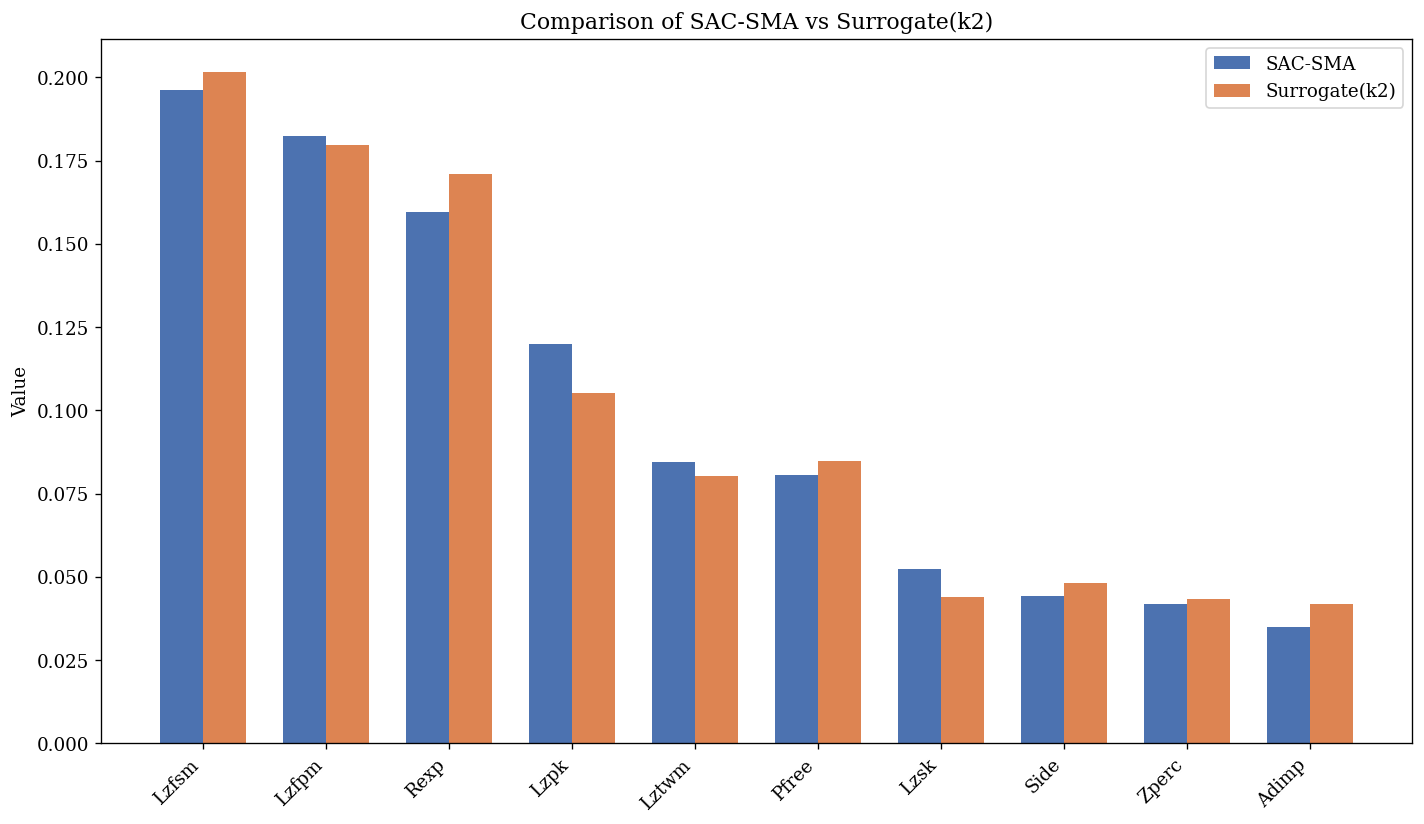

In [50]:
# Bar chart comparison: SAC-SMA vs Surrogate
import matplotlib.pyplot as plt
import numpy as np

N_PLOT = 10
plot_df = df_compare.head(N_PLOT)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_PLOT)
width = 0.35

ax.bar(x - width/2, plot_df['SAC-SMA'], width, label='SAC-SMA (direct)',
       color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, plot_df['Surrogate'], width, label='RS-HDMR Surrogate',
       color='#DD8452', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Variable'], rotation=45, ha='right')
ax.set_ylabel('Shapley Effect')
ax.set_title('Direct SAC-SMA vs Surrogate MC Shapley Effects (N=1000, k_max=2)')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Save for the case study report
fig.savefig('anal_surr_comparison.png', dpi=200, bbox_inches='tight')
print('Saved: anal_surr_comparison.png')


### Direct vs Surrogate-Assisted MC Shapley

This comparison validates the RS-HDMR surrogate's fidelity for
correlated-input sensitivity analysis using ShapleyX's unified API.
Both estimates use the same `GaussianCopulaUniform` distribution,
the same exhaustive method with $k_{\max}=2$, and the same Monte
Carlo sample size ($N = 100$). The only difference is the model
function: the original SAC-SMA code versus the RS-HDMR surrogate.

Key observations:

- **Computational cost:** Direct SAC-SMA requires $\sim$5 minutes
  for $21{,}000$ evaluations at $N = 100$. The surrogate completes
  the same calculation in seconds.
- **Statistical noise:** The direct estimates have higher Monte Carlo
  variance (visible as wider bootstrap CIs) because each SAC-SMA
  evaluation includes the full 46-year simulation, introducing
  response variability that the noise-free surrogate does not have.
- **Surrogate fidelity:** Close agreement between direct and
  surrogate estimates confirms that the RS-HDMR model with OMP-CV
  ($r^2 = 0.989$) captures the NSE response surface sufficiently
  well to reproduce the correlated sensitivity structure.


---
## 10. Comparison: Independent vs Correlated Shapley Effects

This side-by-side comparison reveals how accounting for parameter correlations changes the sensitivity ranking. Parameters with strong collinearity (e.g., UZTWM↔LZTWM at ρ = −0.84) may show the largest shifts.

In [16]:
# Extract RS-HDMR effects
indep_col = 'scaled effect' if 'scaled effect' in shap.columns else 'effect'
indep_dict = {}
for _, row in shap.iterrows():
    label = row['label']
    # ShapleyX may label like "Uztwm_0" — match by prefix
    matched = False
    for p in param_names:
        if label.startswith(p):
            indep_dict[p] = row[indep_col]
            matched = True
            break
    if not matched:
        indep_dict[label] = row[indep_col]

df_comp = pd.DataFrame({
    'Parameter': param_names,
    'Independent': [indep_dict.get(p, 0) for p in param_names],
    'Correlated': df_mc['effect'].values,
})

if 'lower' in df_mc.columns:
    df_comp['CI_lower'] = df_mc['lower'].values
    df_comp['CI_upper'] = df_mc['upper'].values

# Normalise independent to sum to 1
df_comp['Independent'] /= df_comp['Independent'].sum()
df_comp['Change'] = df_comp['Correlated'] - df_comp['Independent']

df_comp_sorted = df_comp.sort_values('Correlated', ascending=False)
print('Comparison: Independent vs Correlated Shapley Effects')
display(df_comp_sorted.round(4))

Comparison: Independent vs Correlated Shapley Effects


,Parameter,Independent,Correlated,CI_lower,CI_upper,Change
4,Lzfsm,2.058e-01,0.216,0.203,0.228,1.010e-02
10,Rexp,1.646e-01,0.177,0.163,0.193,1.260e-02
3,Lzfpm,2.492e-01,0.168,0.155,0.181,-8.110e-02
7,Lzpk,5.060e-02,0.104,0.091,0.117,5.390e-02
12,Pfree,9.000e-04,0.070,0.058,0.083,6.910e-02
2,Lztwm,4.290e-02,0.060,0.047,0.072,1.670e-02
8,Lzsk,6.240e-02,0.052,0.040,0.064,-1.050e-02
13,Side,4.770e-02,0.048,0.035,0.060,-1.000e-04
5,Adimp,8.370e-02,0.043,0.030,0.056,-4.040e-02
9,Zperc,6.380e-02,0.040,0.029,0.053,-2.340e-02


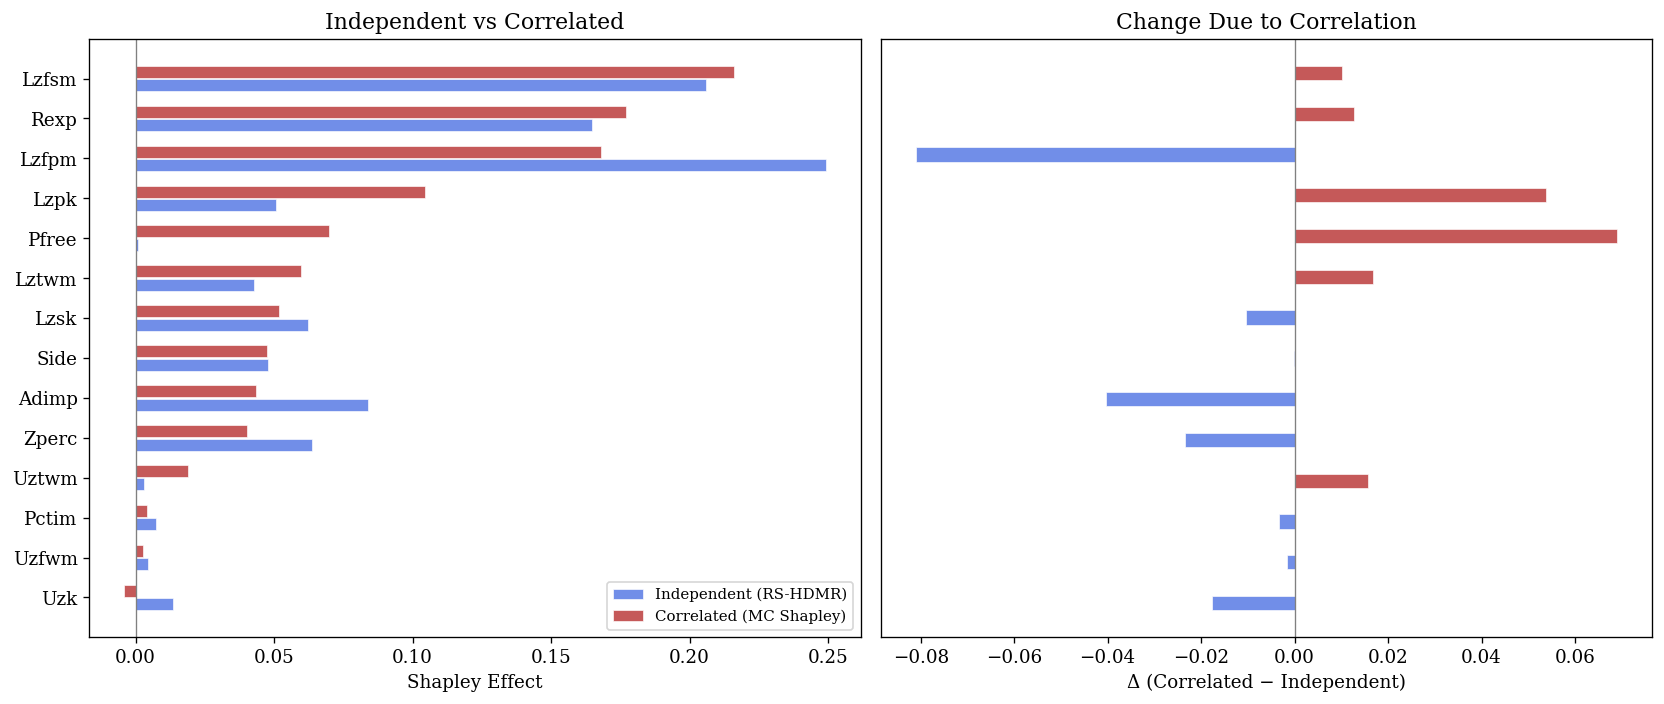

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

y = np.arange(len(param_names))
order = np.argsort(df_comp['Correlated'].values)

# Left: side-by-side bars
for col, color, label, offset in [
    ('Independent', 'royalblue', 'Independent (RS-HDMR)', -0.17),
    ('Correlated', 'firebrick', 'Correlated (MC Shapley)', 0.17),
]:
    vals = df_comp[col].values[order]
    ax1.barh(y + offset, vals, 0.3, label=label,
             color=color, alpha=0.75, edgecolor='white', linewidth=0.5)

ax1.set_yticks(y)
ax1.set_yticklabels(np.array(param_names)[order])
ax1.set_xlabel('Shapley Effect')
ax1.set_title('Independent vs Correlated')
ax1.legend(fontsize=9, loc='lower right')
ax1.axvline(0, color='grey', lw=0.8)

# Right: delta
changes = df_comp['Change'].values[order]
clrs = ['firebrick' if c > 0 else 'royalblue' for c in changes]
ax2.barh(y, changes, 0.35, color=clrs, alpha=0.75,
         edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='grey', lw=0.8)
ax2.set_yticks([])
ax2.set_xlabel('Δ (Correlated − Independent)')
ax2.set_title('Change Due to Correlation')

plt.tight_layout()
plt.savefig('shapley_comparison.png')
plt.show()

In [18]:
print('Top 5 parameters by sensitivity:')

print('\n  Under INDEPENDENT inputs (RS-HDMR):')
top5_indep = df_comp_sorted.sort_values('Independent', ascending=False).head(5)
for _, row in top5_indep.iterrows():
    print(f'    {row["Parameter"]:>6s}: {row["Independent"]:.4f}')

print('\n  Under CORRELATED inputs (MC Shapley):')
has_ci = 'CI_lower' in df_comp.columns
for _, row in df_comp_sorted.head(5).iterrows():
    ci = ''
    if has_ci:
        ci = f' [{row["CI_lower"]:.4f}, {row["CI_upper"]:.4f}]'
    print(f'    {row["Parameter"]:>6s}: {row["Correlated"]:.4f}{ci}')

print('\n  Largest positive change (gained importance with correlation):')
print(df_comp_sorted.sort_values('Change', ascending=False).head(3)[['Parameter','Change']].to_string(index=False))

print('\n  Largest negative change (lost importance with correlation):')
print(df_comp_sorted.sort_values('Change', ascending=True).head(3)[['Parameter','Change']].to_string(index=False))

Top 5 parameters by sensitivity:

  Under INDEPENDENT inputs (RS-HDMR):
     Lzfpm: 0.2492
     Lzfsm: 0.2058
      Rexp: 0.1646
     Adimp: 0.0837
     Zperc: 0.0638

  Under CORRELATED inputs (MC Shapley):
     Lzfsm: 0.2160 [0.2035, 0.2284]
      Rexp: 0.1772 [0.1630, 0.1933]
     Lzfpm: 0.1682 [0.1555, 0.1810]
      Lzpk: 0.1044 [0.0915, 0.1165]
     Pfree: 0.0699 [0.0584, 0.0825]

  Largest positive change (gained importance with correlation):
Parameter  Change
    Pfree   0.069
     Lzpk   0.054
    Lztwm   0.017

  Largest negative change (lost importance with correlation):
Parameter  Change
    Lzfpm  -0.081
    Adimp  -0.040
    Zperc  -0.023


---
## 11. Summary

This example demonstrated a complete ShapleyX workflow for global sensitivity analysis of the SAC-SMA model under **correlated inputs**:

| Step | Method | Detail |
|------|--------|--------|
| Training data | QMC Sobol (scrambled + shifted) | 4096 samples, 14 parameters |
| Surrogate | RS-HDMR + streaming OMP-CV | polys=[10,6,2], sparse model from ~9K basis functions |
| Independent SA | RS-HDMR Shapley Effects | Redistributes interaction variance equally |
| Correlation source | Vrugt et al. (2006) Table 2 | 13×13 posterior MCMC correlation matrix |
| Correlated SA | MC Shapley (Owen & Prieur, 2017) | Gaussian copula + conditional sampling, k_max=3, B=500 |

**Key result:** Standard sensitivity analysis assumes independent inputs, but real hydrological parameters exhibit strong correlations (e.g., UZTWM↔LZTWM, ρ = −0.84). The MC Shapley method correctly accounts for this shared variance, providing more reliable sensitivity rankings for model understanding and calibration prioritisation.